_Permafrost_

1) Analyzing the dataset


In [2]:
import pandas as pd

# Standorte mit Koordinaten
sites = pd.read_csv('/Users/aniellepeterhans/Lede/Data_Project2/PERMOS-DOI-2025-01/Data/site_20250627.csv')

# Bohrlöcher
boreholes = pd.read_csv('/Users/aniellepeterhans/Lede/Data_Project2/PERMOS-DOI-2025-01/Data/borehole_20250627.csv')

# Jährliche Temperaturen
bht = pd.read_csv('/Users/aniellepeterhans/Lede/Data_Project2/PERMOS-DOI-2025-01/Data/bht_year_20250627.csv')

print("Sites:", sites.shape)
print("Boreholes:", boreholes.shape)
print("BHT:", bht.shape)
print(bht.head())

Sites: (27, 25)
Boreholes: (32, 26)
BHT: (8233, 7)
   borehole_id  depth  time     temp    t_min    t_max  count
0           16    9.0  2007 -0.47545 -0.78302 -0.26124     12
1           16    4.0  2016 -0.01649 -0.53446  0.69409     11
2           16    7.0  2012 -0.25406 -0.62333 -0.05066     11
3           16   11.0  2018 -0.16846 -0.28740 -0.04305     11
4           16    4.0  2000 -0.29103 -1.06290  0.43378     12


2) borehole → site verknüpfen / Messungen

In [3]:
# borehole → site verknüpfen
bh = boreholes[['id', 'site_id', 'name', 'lat', 'lon', 'depth']].rename(columns={'id': 'borehole_id', 'depth': 'borehole_depth'})

# join mit temperaturen
df_perm = bht.merge(bh, on='borehole_id', how='left')

# join mit site namen
df_perm = df_perm.merge(sites[['id', 'name', 'abbr', 'lat', 'lon']], 
                         left_on='site_id', right_on='id', 
                         suffixes=('_bh', '_site'))

print(df_perm.shape)
print(df_perm[['name_site', 'lat_site', 'lon_site', 'depth', 'time', 'temp']].head(10))

(8233, 17)
    name_site   lat_site  lon_site  depth  time     temp
0  Schilthorn  46.558281  7.834621    9.0  2007 -0.47545
1  Schilthorn  46.558281  7.834621    4.0  2016 -0.01649
2  Schilthorn  46.558281  7.834621    7.0  2012 -0.25406
3  Schilthorn  46.558281  7.834621   11.0  2018 -0.16846
4  Schilthorn  46.558281  7.834621    4.0  2000 -0.29103
5  Schilthorn  46.558281  7.834621   13.0  2024  0.19933
6  Schilthorn  46.558281  7.834621    3.0  2010  0.06525
7  Schilthorn  46.558281  7.834621    7.0  2017 -0.11959
8  Schilthorn  46.558281  7.834621    2.0  2016  0.10015
9  Schilthorn  46.558281  7.834621    5.0  2023  0.52686


In [5]:
# 8233 Messungen mit Standort, Tiefe, Jahr und Temperatur

In [4]:
# Temperaturtrend pro Standort bei ~10m Tiefe --> 9-11 Meter ist eine Standard-Referenztiefe in der Permafrostforschung, 
# weniger von saisonalen Schwankungen beeinflusst als oberflächennahe Messpunkte

df_10m = df_perm[df_perm['depth'].between(9, 11)].copy()

# Trend pro Standort über alle Jahre
trend = df_10m.groupby(['name_site', 'time', 'lat_site', 'lon_site'])['temp'].mean().reset_index()

print(trend['name_site'].unique())
print(trend.shape)
trend.sort_values(['name_site', 'time']).head(15)

<StringArray>
[              'Flüela',            'Gemsstock',            'Gentianes',
             'Jungfrau',              'Lapires',          'Les Attelas',
           'Matterhorn', 'Muot da Barba Peider',               'Muragl',
     'Murtèl-Corvatsch',           'Ritigraben',            'Schafberg',
           'Schilthorn',            'Stockhorn',                'Tsaté']
Length: 15, dtype: str
(275, 5)


,name_site,time,lat_site,lon_site,temp
0,Flüela,2016,46.747924,9.945148,-0.12723
1,Flüela,2017,46.747924,9.945148,-0.15983
2,Flüela,2018,46.747924,9.945148,-0.20934
3,Flüela,2019,46.747924,9.945148,-0.19574
4,Flüela,2020,46.747924,9.945148,-0.13915
5,Flüela,2021,46.747924,9.945148,-0.09803
6,Flüela,2022,46.747924,9.945148,-0.07747
7,Gemsstock,2007,46.601328,8.610423,0.32941
8,Gemsstock,2008,46.601328,8.610423,0.21277
9,Gemsstock,2009,46.601328,8.610423,0.46357


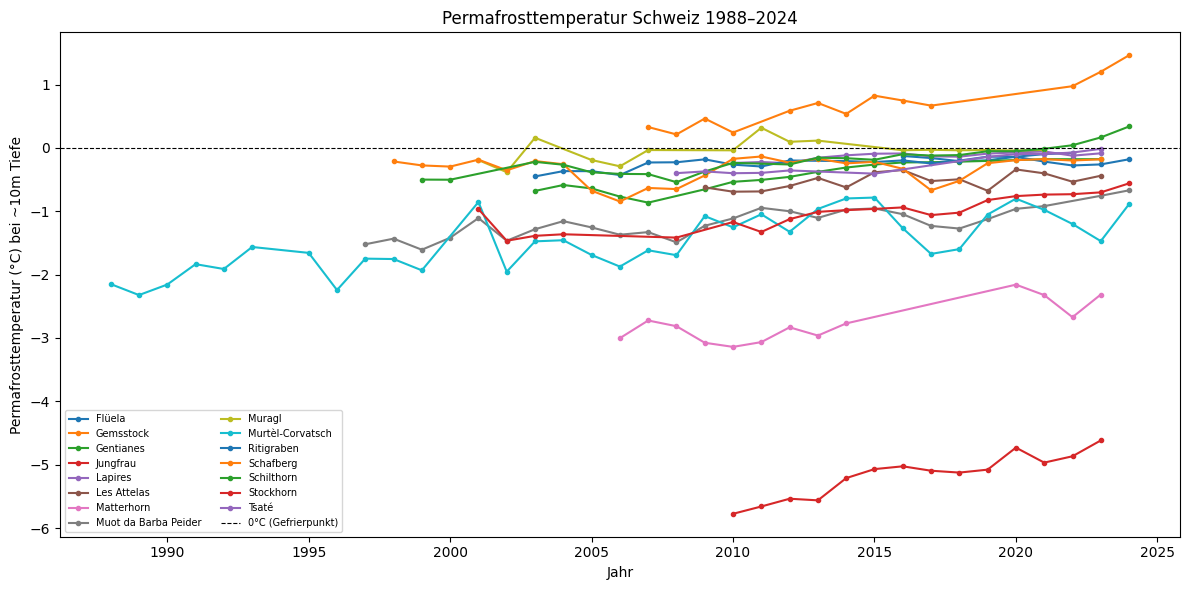

In [5]:
#plotting

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for site in trend['name_site'].unique():
    d = trend[trend['name_site'] == site].sort_values('time')
    ax.plot(d['time'], d['temp'], marker='o', markersize=3, label=site)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='0°C (Gefrierpunkt)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Permafrosttemperatur (°C) bei ~10m Tiefe')
ax.set_title('Permafrosttemperatur Schweiz 1988–2024')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [6]:
import json

# Für die Karte: letzter verfügbarer Wert + Trend pro Standort
summary = []

for site in trend['name_site'].unique():
    d = trend[trend['name_site'] == site].sort_values('time')
    
    first = d.iloc[0]
    last = d.iloc[-1]
    change = last['temp'] - first['temp']
    
    summary.append({
        'name': site,
        'lat': last['lat_site'],
        'lon': last['lon_site'],
        'temp_first': round(first['temp'], 3),
        'year_first': int(first['time']),
        'temp_last': round(last['temp'], 3),
        'year_last': int(last['time']),
        'temp_change': round(change, 3)
    })

df_summary = pd.DataFrame(summary)
print(df_summary.sort_values('temp_change', ascending=False))

                    name        lat       lon  temp_first  year_first  \
9       Murtèl-Corvatsch  46.428791  9.821810      -2.149        1988   
3               Jungfrau  46.546110  7.973192      -5.775        2010   
1              Gemsstock  46.601328  8.610423       0.329        2007   
7   Muot da Barba Peider  46.496467  9.930897      -1.521        1997   
12            Schilthorn  46.558281  7.834621      -0.500        1999   
6             Matterhorn  45.982321  7.676049      -3.003        2006   
2              Gentianes  46.083705  7.302472      -0.679        2003   
13             Stockhorn  45.986786  7.824201      -0.966        2001   
14                 Tsaté  46.109047  7.548442      -0.398        2008   
10            Ritigraben  46.174426  7.849561      -0.450        2003   
5            Les Attelas  46.096387  7.273774      -0.623        2009   
8                 Muragl  46.507784  9.927833      -0.192        2001   
4                Lapires  46.106117  7.284349      

In [12]:
# Alle 15 Standorte zeigen steigende Permafrosttemperaturen. Murtèl-Corvatsch +1.26°C seit 1988, Jungfrau +1.16°C seit 2010.

3) als JSON exportieren

In [7]:
# Summary als GeoJSON für Mapbox
features = []
for _, row in df_summary.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [row['lon'], row['lat']]},
        "properties": {
            "name": row['name'],
            "temp_first": row['temp_first'],
            "year_first": int(row['year_first']),
            "temp_last": row['temp_last'],
            "year_last": int(row['year_last']),
            "temp_change": row['temp_change']
        }
    })

with open('/Users/aniellepeterhans/Lede/Data_Project2/permafrost.geojson', 'w') as f:
    json.dump({"type": "FeatureCollection", "features": features}, f)

# Zeitreihen als JSON für Charts
timeseries = {}
for site in trend['name_site'].unique():
    d = trend[trend['name_site'] == site].sort_values('time')
    timeseries[site] = [{"year": int(r['time']), "temp": round(r['temp'], 3)} for _, r in d.iterrows()]

with open('/Users/aniellepeterhans/Lede/Data_Project2/permafrost_timeseries.json', 'w') as f:
    json.dump(timeseries, f)